# Task 2.1: Dataset Selection and Setup

## Justification
The dataset is `SimpleDeformableCross`, a synthetic 12x12 image dataset generated here. The method proposed in the paper relies on a multi-layer grid (1x1, 3x3, 6x6). A 12x12 image perfectly maps to these spatial pools (12x12 root, 4x4 middle layer, 2x2 bottom layer parts). It is an ideal testbed because the positive class consists of a "cross" shape separated into 5 spatial sub-parts (center, top, bottom, left, right) which randomly jitter by 1-2 pixels. This perfectly satisfies the requirement of testing the shape deformation ($\Phi_S$) and appearance features ($\Phi_A$) described in the paper. It is limited compared to real PASCAL VOC images by being far lower resolution, single channel, and lacking background clutter.

## Code: Dataset Generation
This steps generates the toy dataset and saves it to the `data/` folder for reproducibility.

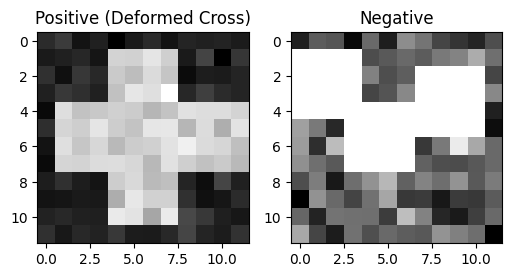

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
np.random.seed(42)

def generate_cross(deform=True):
    img = np.zeros((12, 12))
    # Base shape: center 4x4 at (4,4), top (0,4), bot (8,4), left (4,0), right (4,8)
    parts = [(4,4), (0,4), (8,4), (4,0), (4,8)]
    for (y, x) in parts:
        dy = np.random.randint(-1, 2) if deform and y in [0, 8] else 0
        dx = np.random.randint(-1, 2) if deform and x in [0, 8] else 0
        py, px = max(0, min(8, y+dy)), max(0, min(8, x+dx))
        img[py:py+4, px:px+4] = 1.0
    return img + np.random.normal(0, 0.1, (12,12))

def generate_negative():
    img = np.random.normal(0, 0.3, (12,12))
    for _ in range(3):
        y, x = np.random.randint(0, 8, 2)
        img[y:y+4, x:x+4] = 1.0
    return img

X_train = np.array([generate_cross() for _ in range(100)] + [generate_negative() for _ in range(100)])
y_train = np.array([1]*100 + [-1]*100)

X_test = np.array([generate_cross() for _ in range(50)] + [generate_negative() for _ in range(50)])
y_test = np.array([1]*50 + [-1]*50)

os.makedirs('data', exist_ok=True)
np.save('data/X_train.npy', X_train)
np.save('data/y_train.npy', y_train)
np.save('data/X_test.npy', X_test)
np.save('data/y_test.npy', y_test)

fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(X_train[0], cmap='gray'); axes[0].set_title('Positive (Deformed Cross)')
axes[1].imshow(X_train[-1], cmap='gray'); axes[1].set_title('Negative')
plt.savefig('results/data_samples.png')
plt.show()
